# Social Post Conversion Classifier (Post Type + Interactions)

## 1. Problem Framing
- **Business question:** Which social posts are most likely to generate at least one donation referral soon after publishing?
- **Predictive goal:** classify whether a post will drive at least one linked donation within 7 days.
- **Explanatory goal:** identify interaction/content patterns associated with higher conversion likelihood.
- **Why it matters:** helps staff prioritize post design (type, CTA, hashtags, media, timing) for fundraising impact.

## Run Instructions
- Run from repository root.
- This notebook first tries `./lighthouse_csv_v7` and then falls back to `./backend/csv`.
- Uses shared `ml-pipelines/functions.py` cleaning helpers by project convention.

In [5]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, precision_score, recall_score

sys.path.append(str(Path('ml-pipelines').resolve()))
from functions import basic_cleaning, missing_value_summary, numeric_summary, categorical_summary

DATA_CANDIDATES = [
    Path('lighthouse_csv_v7'),
    Path('../backend') / 'csv',
]
DATA = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA is None:
    raise FileNotFoundError(
        "Missing data folder. Expected './lighthouse_csv_v7/' or './backend/csv/' from repo root."
    )
print(f'Using data folder: {DATA.resolve()}')

posts = pd.read_csv(DATA / 'social_media_posts.csv', parse_dates=['created_at'])
don = pd.read_csv(DATA / 'donations.csv', parse_dates=['donation_date'])

posts = basic_cleaning(posts, date_columns=['created_at'])
don = basic_cleaning(don, date_columns=['donation_date'], numeric_columns=['referral_post_id', 'amount', 'estimated_value'])

print('posts shape:', posts.shape)
print('donations shape:', don.shape)

Using data folder: C:\Users\joshu\OneDrive\IS CORE\realINTEXpt2\Intex-2\backend\csv
posts shape: (812, 39)
donations shape: (420, 13)


## 2. Data Acquisition, Preparation, and Exploration
- **Sources used:** `social_media_posts` + `donations`.
- **Join key:** `social_media_posts.post_id` to `donations.referral_post_id`.
- **Target definition:** at least one linked donation within 7 days after post publish time (`converted_7d`).
- **Leakage guard:** post-outcome columns (`donation_referrals`, `estimated_donation_value_php`) are excluded as model features.


In [6]:
# Build leakage-safe target from linked donations in a 7-day post window.
posts = posts.dropna(subset=['post_id', 'created_at']).copy()
posts['post_id'] = pd.to_numeric(posts['post_id'], errors='coerce')
posts = posts.dropna(subset=['post_id']).copy()
posts['post_id'] = posts['post_id'].astype(int)

don_ref = don.dropna(subset=['referral_post_id', 'donation_date']).copy()
don_ref['referral_post_id'] = pd.to_numeric(don_ref['referral_post_id'], errors='coerce')
don_ref = don_ref.dropna(subset=['referral_post_id']).copy()
don_ref['referral_post_id'] = don_ref['referral_post_id'].astype(int)

m = posts[['post_id', 'created_at']].merge(
    don_ref[['referral_post_id', 'donation_date', 'amount', 'estimated_value']],
    left_on='post_id',
    right_on='referral_post_id',
    how='left'
)
m = m[(m['donation_date'] >= m['created_at']) & (m['donation_date'] <= m['created_at'] + pd.Timedelta(days=7))]

target_agg = m.groupby('post_id').agg(
    referred_donation_count_7d=('donation_date', 'count'),
    referred_donation_value_7d=('amount', 'sum')
).reset_index()

df = posts.merge(target_agg, on='post_id', how='left')
df['referred_donation_count_7d'] = df['referred_donation_count_7d'].fillna(0)
df['referred_donation_value_7d'] = df['referred_donation_value_7d'].fillna(0)
df['converted_7d'] = (df['referred_donation_count_7d'] > 0).astype(int)

# Feature engineering from interaction/content fields.
df['engagement_total'] = (
    pd.to_numeric(df.get('likes', 0), errors='coerce').fillna(0)
    + pd.to_numeric(df.get('comments', 0), errors='coerce').fillna(0)
    + pd.to_numeric(df.get('shares', 0), errors='coerce').fillna(0)
    + pd.to_numeric(df.get('saves', 0), errors='coerce').fillna(0)
)
df['has_hashtags'] = (pd.to_numeric(df.get('num_hashtags', 0), errors='coerce').fillna(0) > 0).astype(int)
df['is_evening_post'] = pd.to_numeric(df.get('post_hour', 0), errors='coerce').fillna(0).between(17, 22).astype(int)

# Exclude direct leakage / target proxies from feature set.
exclude_cols = {
    'converted_7d', 'referred_donation_count_7d', 'referred_donation_value_7d',
    'donation_referrals', 'estimated_donation_value_php', 'post_id', 'created_at'
}
feature_cols = [c for c in [
    'platform', 'day_of_week', 'post_hour', 'post_type', 'media_type',
    'content_topic', 'sentiment_tone', 'has_call_to_action', 'call_to_action_type',
    'features_resident_story', 'is_boosted', 'boost_budget_php', 'caption_length',
    'num_hashtags', 'mentions_count', 'impressions', 'reach', 'likes', 'comments',
    'shares', 'saves', 'click_throughs', 'video_views', 'engagement_rate', 'profile_visits',
    'engagement_total', 'has_hashtags', 'is_evening_post'
] if c in df.columns and c not in exclude_cols]

model_df = df[feature_cols + ['converted_7d', 'created_at']].copy().sort_values('created_at')
print('Model rows:', len(model_df))
print('Conversion rate:', round(model_df['converted_7d'].mean() * 100, 2), '%')
print('Missingness summary (top 10):')
print(missing_value_summary(model_df).head(10).to_string())

Model rows: 812
Conversion rate: 7.64 %
Missingness summary (top 10):
                     missing_count  missing_pct
boost_budget_php               685        84.36
video_views                    479        58.99
call_to_action_type            319        39.29


## 3. Modeling and Feature Selection
- **Explanatory baseline:** Logistic Regression for directional interpretation.
- **Predictive model:** Random Forest for nonlinear interaction capture.
- **Feature rationale:** post type, media, CTA, timing, hashtags, and interaction intensity are all operationally actionable.


In [7]:
# Chronological split to mimic real forecasting.
cut = int(len(model_df) * 0.8)
train_df = model_df.iloc[:cut].copy()
test_df = model_df.iloc[cut:].copy()

X_train = train_df[feature_cols].copy()
y_train = train_df['converted_7d']
X_test = test_df[feature_cols].copy()
y_test = test_df['converted_7d']

num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

# Normalize dtypes explicitly to avoid mixed-type preprocessing errors.
for c in num_cols:
    X_train[c] = pd.to_numeric(X_train[c], errors='coerce')
    X_test[c] = pd.to_numeric(X_test[c], errors='coerce')

for c in cat_cols:
    X_train[c] = X_train[c].astype('object').fillna('Unknown')
    X_test[c] = X_test[c].astype('object').fillna('Unknown')

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
])

exp_model = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
pred_model = Pipeline([
    ('pre', pre),
    ('clf', RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced_subsample'))
])

def evaluate(name, model):
    model.fit(X_train, y_train)
    s = model.predict_proba(X_test)[:, 1]
    p = (s >= 0.5).astype(int)
    print(name)
    print('AUC', round(roc_auc_score(y_test, s), 3),
          'PR_AUC', round(average_precision_score(y_test, s), 3),
          'F1', round(f1_score(y_test, p, zero_division=0), 3),
          'Precision', round(precision_score(y_test, p, zero_division=0), 3),
          'Recall', round(recall_score(y_test, p, zero_division=0), 3))
    print('-' * 70)

evaluate('Explanatory_Logistic', exp_model)
evaluate('Predictive_RF', pred_model)

Explanatory_Logistic
AUC 0.662 PR_AUC 0.172 F1 0.255 Precision 0.175 Recall 0.467
----------------------------------------------------------------------
Predictive_RF
AUC 0.744 PR_AUC 0.208 F1 0.0 Precision 0.0 Recall 0.0
----------------------------------------------------------------------


## 4. Evaluation and Interpretation
- Metrics are reported as AUC, PR-AUC, F1, precision, and recall on chronological holdout data.
- Use this pipeline for **decision support** and ranking content options, not causal claims.
- If precision is low but recall is high, use scores to prioritize review rather than automated decisions.


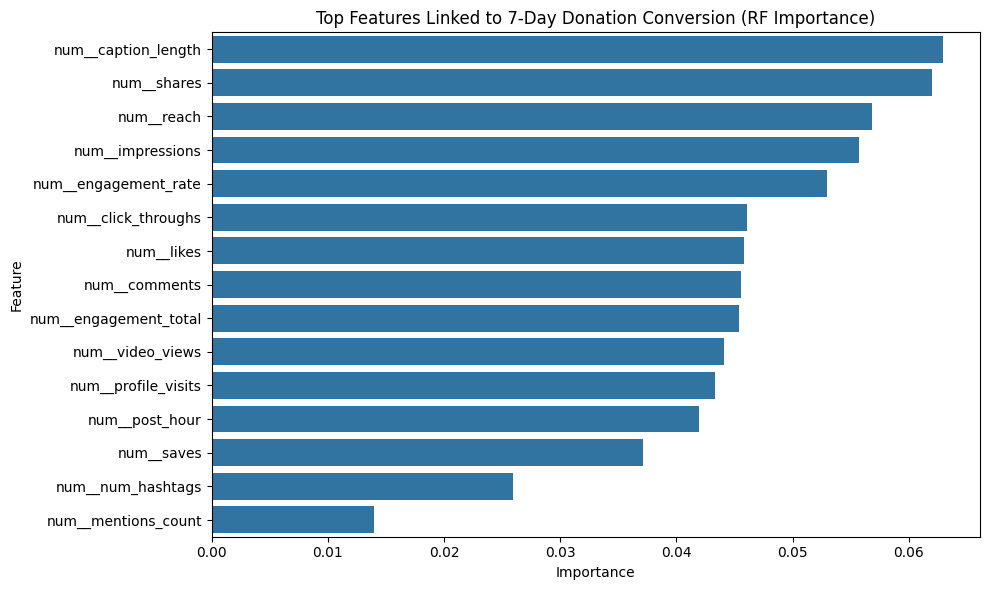

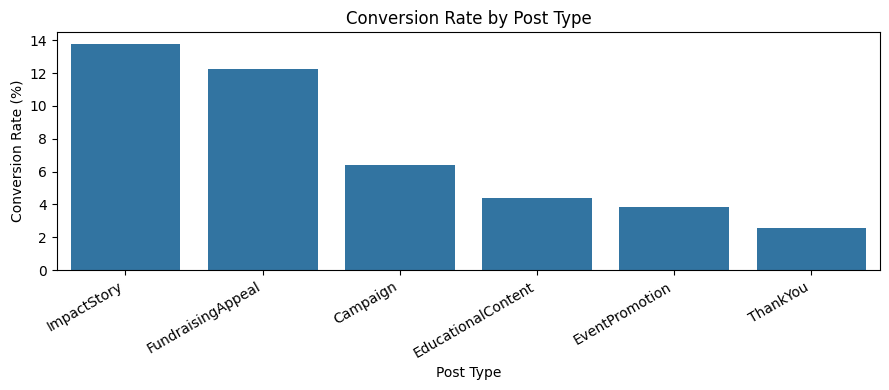

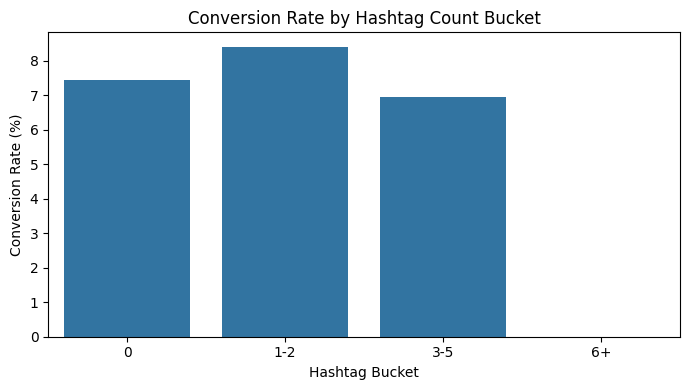

Top interaction/content patterns (descriptive):


,post_type,converted_7d,converted_7d_pct
4,ImpactStory,0.137931,13.793103
3,FundraisingAppeal,0.122222,12.222222
0,Campaign,0.064103,6.410256
1,EducationalContent,0.043860,4.385965
2,EventPromotion,0.038168,3.816794
5,ThankYou,0.025424,2.542373


In [8]:
## 5. Results Visualization (Interactions + Content)

# Refit RF for feature importance chart.
pred_model.fit(X_train, y_train)
rf = pred_model.named_steps['clf']
feature_names = pred_model.named_steps['pre'].get_feature_names_out()
imp = pd.DataFrame({'feature': feature_names, 'importance': rf.feature_importances_})
imp = imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp, x='importance', y='feature', orient='h')
plt.title('Top Features Linked to 7-Day Donation Conversion (RF Importance)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Content-type conversion rates.
if 'post_type' in df.columns:
    conv_by_type = df.groupby('post_type', dropna=False)['converted_7d'].mean().reset_index()
    conv_by_type['converted_7d_pct'] = conv_by_type['converted_7d'] * 100
    conv_by_type = conv_by_type.sort_values('converted_7d_pct', ascending=False)

    plt.figure(figsize=(9, 4))
    sns.barplot(data=conv_by_type, x='post_type', y='converted_7d_pct')
    plt.title('Conversion Rate by Post Type')
    plt.xlabel('Post Type')
    plt.ylabel('Conversion Rate (%)')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# Hashtag-intensity conversion rates.
if 'num_hashtags' in df.columns:
    h = pd.to_numeric(df['num_hashtags'], errors='coerce').fillna(0)
    df['hashtag_bucket'] = pd.cut(
        h,
        bins=[-0.1, 0, 2, 5, 100],
        labels=['0', '1-2', '3-5', '6+']
    )
    conv_by_hash = df.groupby('hashtag_bucket', dropna=False)['converted_7d'].mean().reset_index()
    conv_by_hash['converted_7d_pct'] = conv_by_hash['converted_7d'] * 100

    plt.figure(figsize=(7, 4))
    sns.barplot(data=conv_by_hash, x='hashtag_bucket', y='converted_7d_pct')
    plt.title('Conversion Rate by Hashtag Count Bucket')
    plt.xlabel('Hashtag Bucket')
    plt.ylabel('Conversion Rate (%)')
    plt.tight_layout()
    plt.show()

print('Top interaction/content patterns (descriptive):')
display(conv_by_type.head(10) if 'post_type' in df.columns else pd.DataFrame({'note': ['post_type not found']}))

## 6. Deployment Notes
- Candidate endpoint: `POST /api/ml/social-post-conversion`.
- Input: pre-publish (and optional early interaction) post attributes.
- Output: probability of at least one linked donation within 7 days, plus key feature drivers.
- UI usage: content-planning support tool on Reports/Admin pages to prioritize high-conversion post designs.
- Causality caveat: this pipeline estimates association/prediction, not causal lift.